# 🏃‍♂️ ACL Gait Biomechanics Pipeline (Refined)

이 노트북은 보행 시계열 데이터의 파이프라인(전처리, 통계 시각화)을 단일 지점에서 실행할 수 있도록 통합된 환경입니다.
**비대칭 IQR 아웃라이어 제거** 및 **LMM, 사후검정, 상관관계 분석**까지 자동 수행됩니다.

In [1]:
import sys
import os
import pandas as pd

# 모듈이 위치한 프로젝트 루트 경로를 시스템 경로에 추가
ROOT_DIR = os.path.dirname(os.getcwd())
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from scripts.analysis import preprocess, statistics, visualize

## 1. Parameters Setup
비대칭 IQR 계수와 피크 탐색 조건을 조절하여 민감도를 설정합니다.

In [2]:
# 피크 감지 제어 변수 (100Hz 기준)
DISTANCE_VAL   = 100    # 최소 간격 (0.5+초 보장 방어)
PROMINENCE_VAL = 1.0    # 노이즈 오탐 방지 돌출량

# 아웃라이어 필터링 (비대칭 IQR 곱셈값)
IQR_UPPER = 2.5
IQR_LOWER = 1.5

print(f"✅ Params Set: DIST={DISTANCE_VAL}, PROM={PROMINENCE_VAL}, IQR=[{IQR_LOWER}, {IQR_UPPER}]")

✅ Params Set: DIST=100, PROM=1.0, IQR=[1.5, 2.5]


## 2. Execute Full Pipeline

In [3]:
# 1단계: 전처리 (피크 추출 및 시공간 데이터 병합)
full_df = preprocess.run_preprocessing(
    distance_val=DISTANCE_VAL,
    prominence_val=PROMINENCE_VAL,
    iqr_upper=IQR_UPPER,
    iqr_lower=IQR_LOWER
)

# 2단계: 통계 분석 (LMM + 사후검정 + Point-Biserial)
stats_df, corr_df = statistics.run_statistics()


▶ 전처리 파이프라인 시작 (분리된 모듈)
✅ 전처리 완료. 결과 저장됨: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\mds\analysis_data.csv
▶ 통계 분석 파이프라인 시작 (분리된 모듈)
✅ 통계 분석 완료. 결과 저장됨: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\mds\stats_result.csv
✅ 상관관계 분석 완료. 결과 저장됨: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\mds\correlation_result.csv


In [5]:
stats_df

,feature,shapiro_normal,levene_equal_var,model,p_group_main,p_interaction,effect_metric,effect_size,tukey_p_ACLD_vs_ACLR,tukey_p_ACLD_vs_Healthy,tukey_p_ACLR_vs_Healthy,dunn_p_ACLD_vs_ACLR,dunn_p_ACLD_vs_Healthy,dunn_p_ACLR_vs_Healthy
0,hip_flexion_injured,True,True,LMM,0.0000,0.4800,partial_eta_sq,0.0151,0.2070,0.2783,0.9874,NaN,NaN,NaN
1,hip_adduction_injured,False,True,Kruskal-Wallis,0.3631,NaN,epsilon_sq,0.0001,NaN,NaN,NaN,0.8871,0.5400,1.0000
2,knee_flexion_injured,False,True,Kruskal-Wallis,0.4067,NaN,epsilon_sq,-0.0009,NaN,NaN,NaN,1.0000,1.0000,0.5324
3,knee_adduction_injured,False,True,Kruskal-Wallis,0.5446,NaN,epsilon_sq,-0.0034,NaN,NaN,NaN,1.0000,1.0000,0.7577
4,knee_int_rotation_injured,False,True,Kruskal-Wallis,0.0015,NaN,epsilon_sq,0.0478,NaN,NaN,NaN,0.0025,1.0000,0.0146
5,ankle_dorsiflexion_injured,False,False,Kruskal-Wallis,0.0432,NaN,epsilon_sq,0.0185,NaN,NaN,NaN,0.8824,0.0387,0.4345
6,hip_flexion_contralateral,False,True,Kruskal-Wallis,0.0547,NaN,epsilon_sq,0.0165,NaN,NaN,NaN,0.0864,1.0000,0.1710
7,knee_flexion_contralateral,False,True,Kruskal-Wallis,0.0020,NaN,epsilon_sq,0.0452,NaN,NaN,NaN,0.3694,0.1704,0.0010
8,ankle_dorsiflexion_contralateral,False,True,Kruskal-Wallis,0.0952,NaN,epsilon_sq,0.0117,NaN,NaN,NaN,0.1166,1.0000,0.3237
9,hip_flexion_LSI,False,True,Kruskal-Wallis,0.2484,NaN,epsilon_sq,0.0034,NaN,NaN,NaN,1.0000,1.0000,0.2893


▶ 시각화 파이프라인 시작 (분리된 모듈)
  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_hip_flexion_injured.png


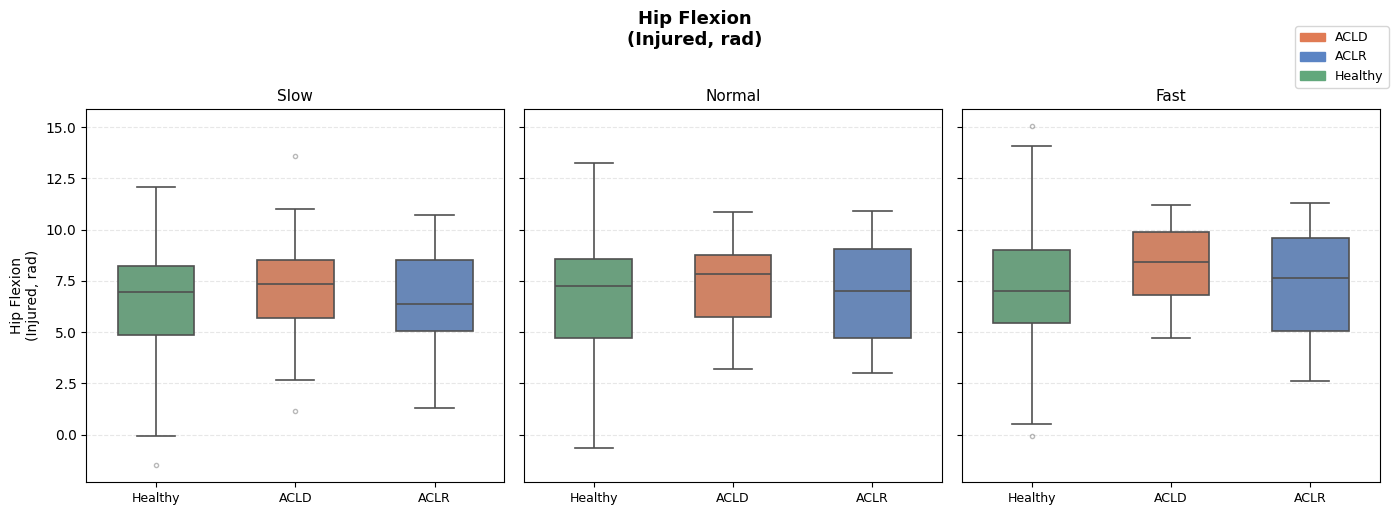

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_hip_adduction_injured.png


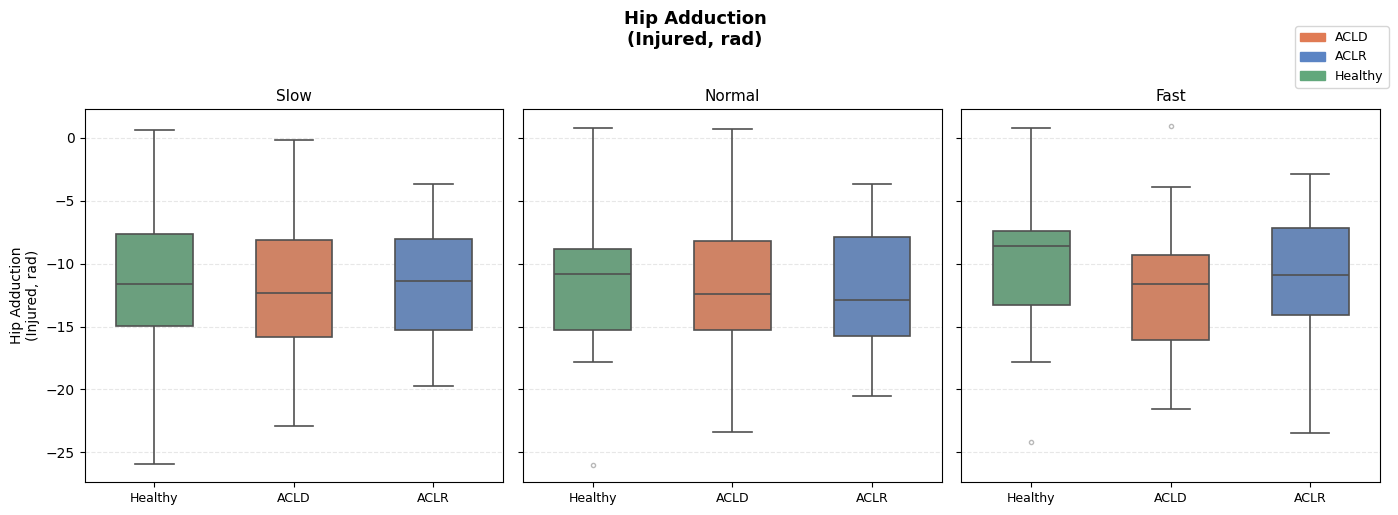

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_knee_flexion_injured.png


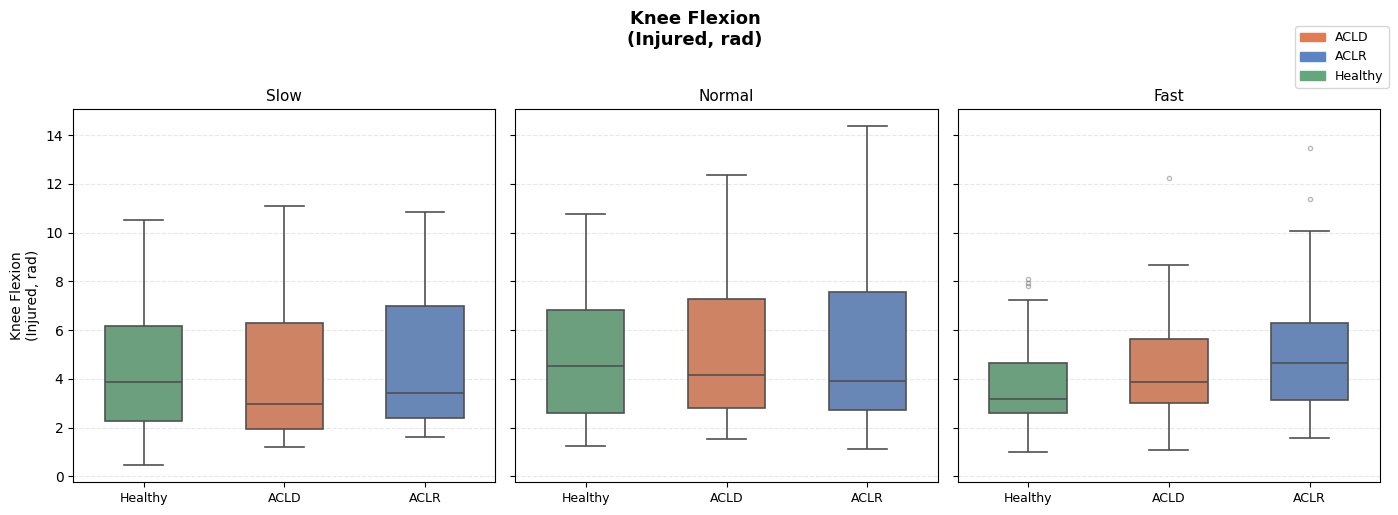

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_knee_adduction_injured.png


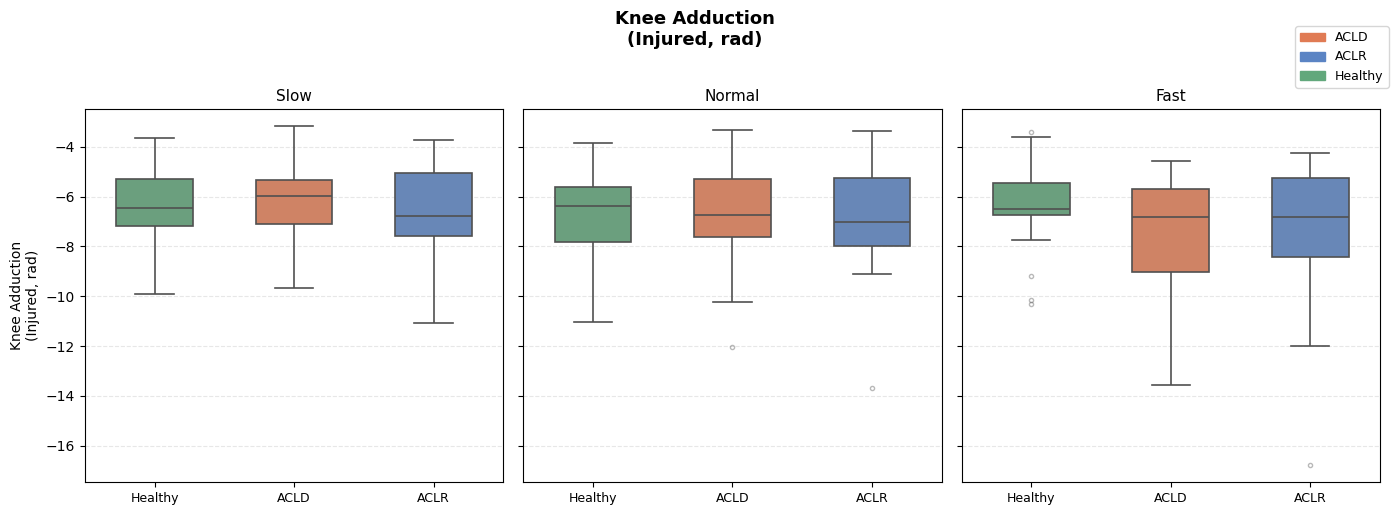

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_knee_int_rotation_injured.png


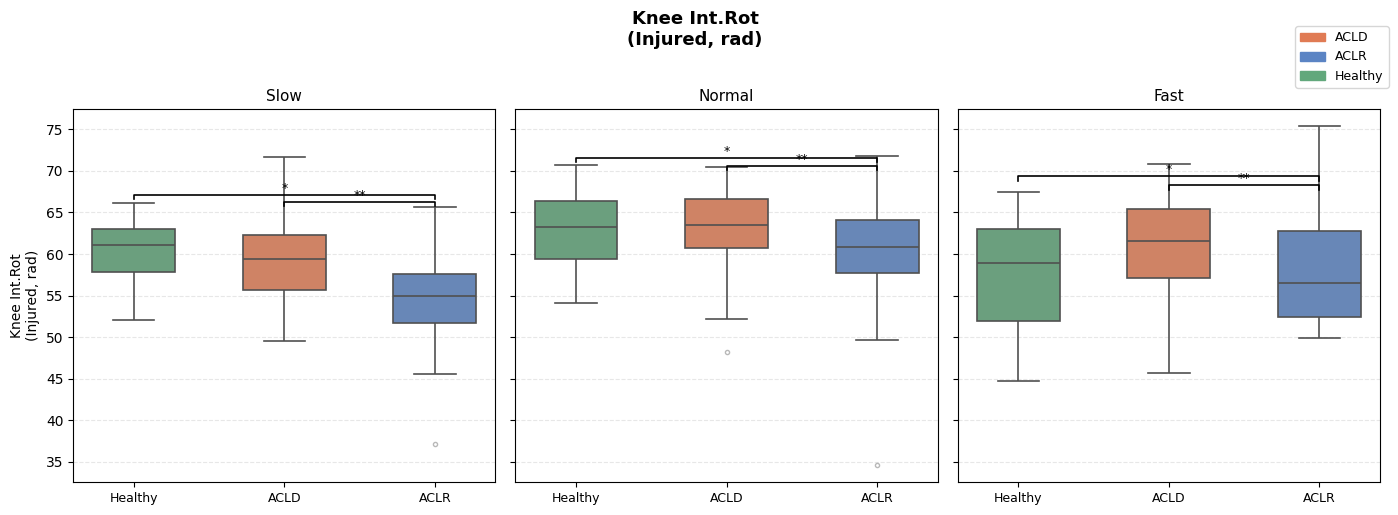

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_ankle_dorsiflexion_injured.png


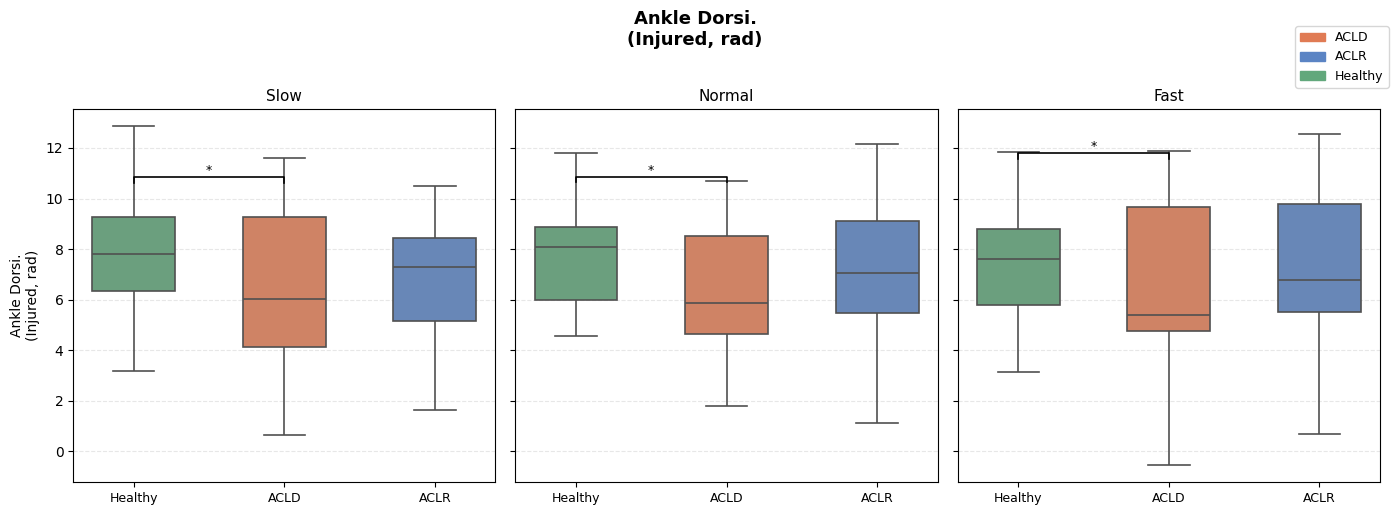

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_hip_flexion_contralateral.png


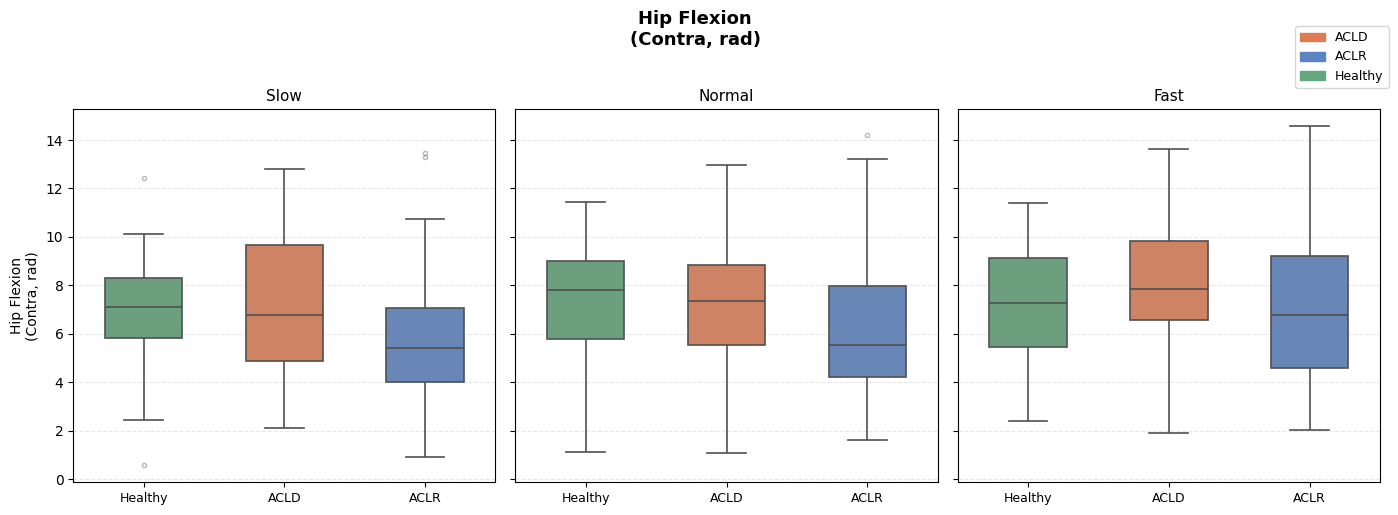

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_knee_flexion_contralateral.png


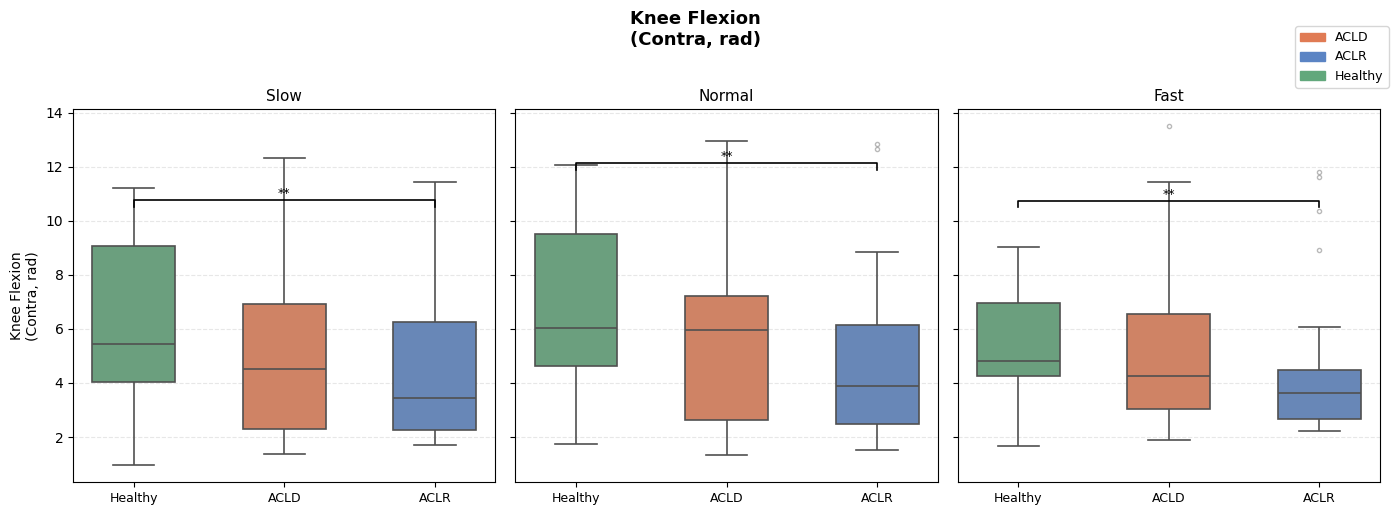

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_ankle_dorsiflexion_contralateral.png


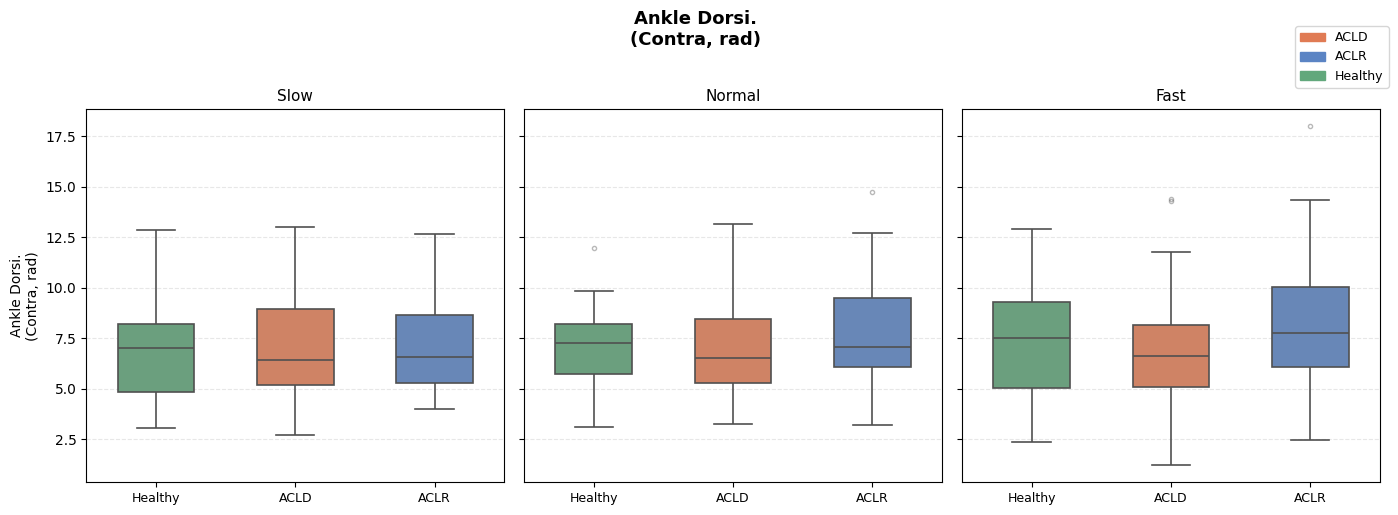

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_hip_flexion_LSI.png


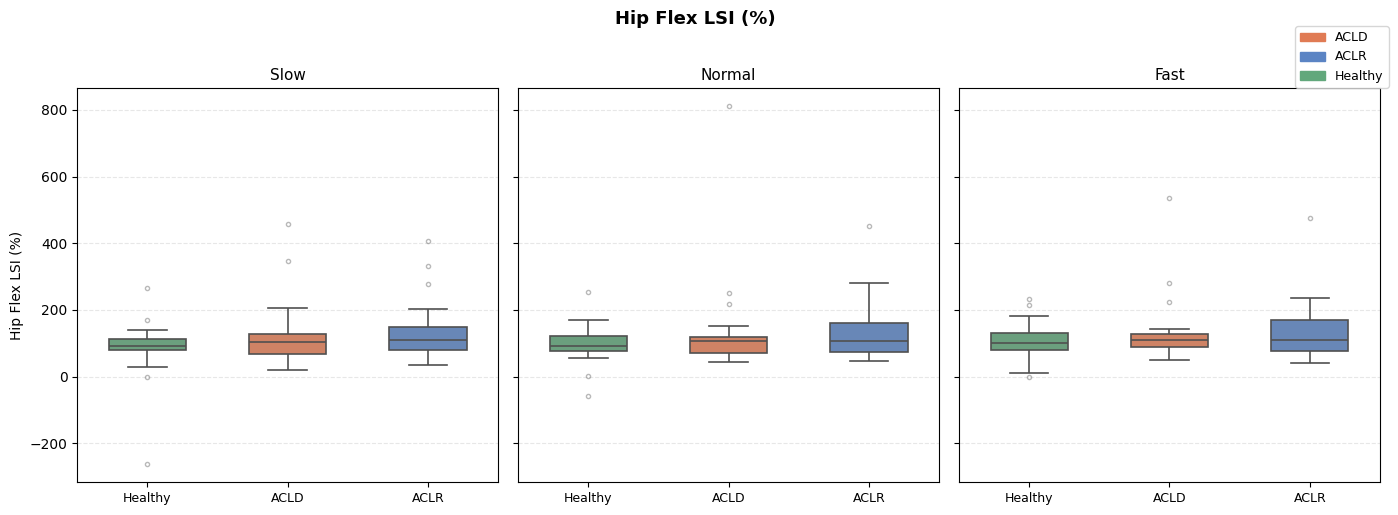

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_knee_flexion_LSI.png


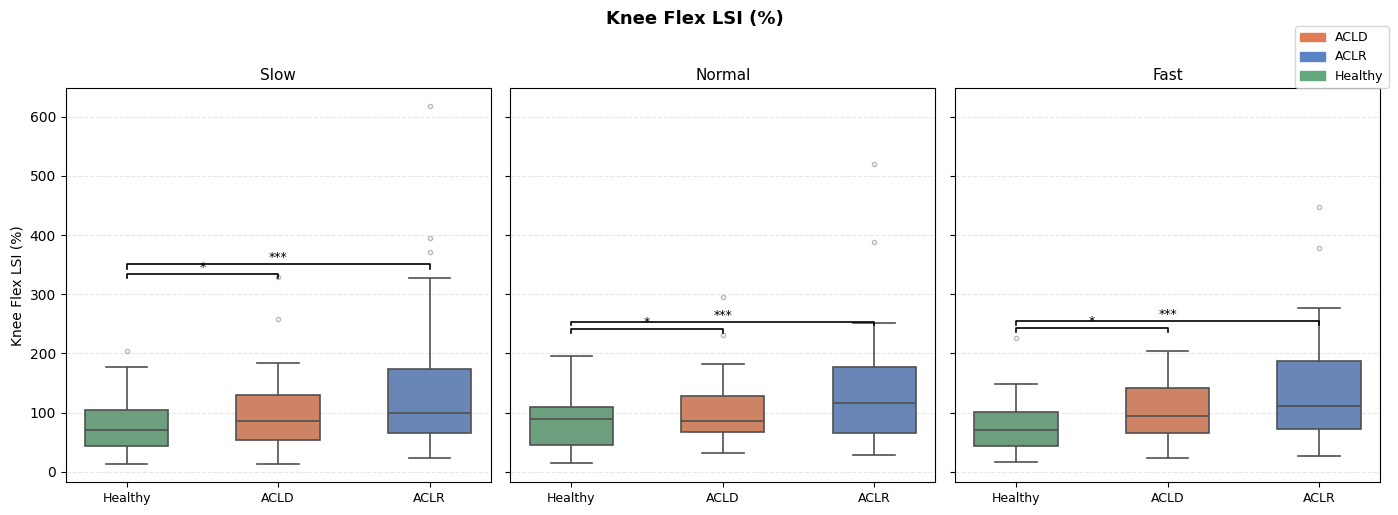

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_ankle_dorsiflexion_LSI.png


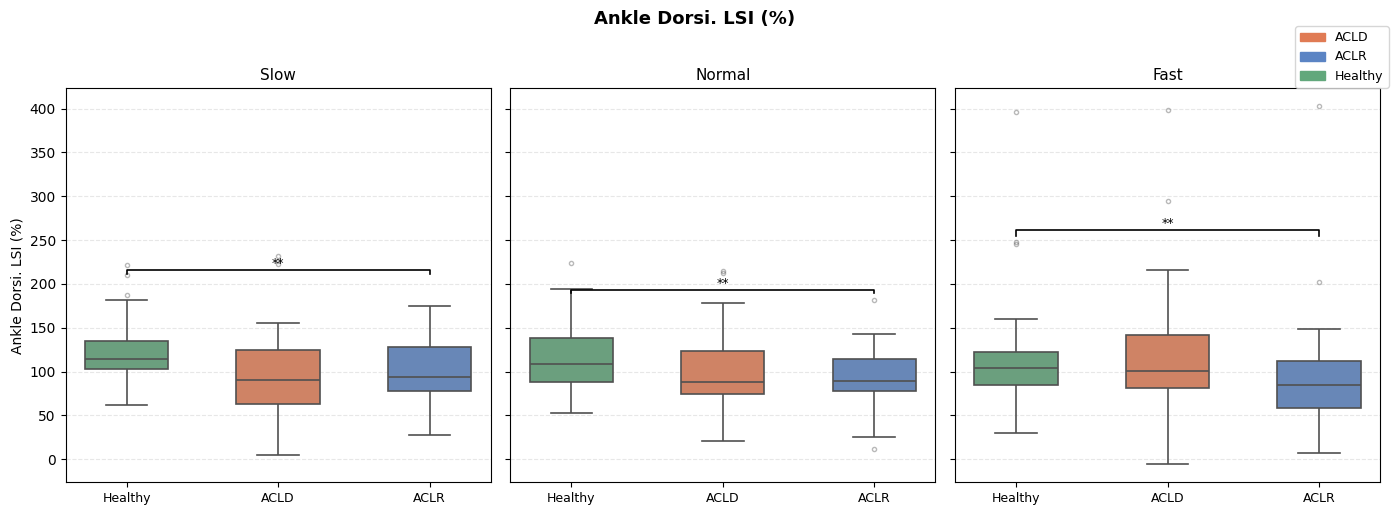

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_gait_speed_mps.png


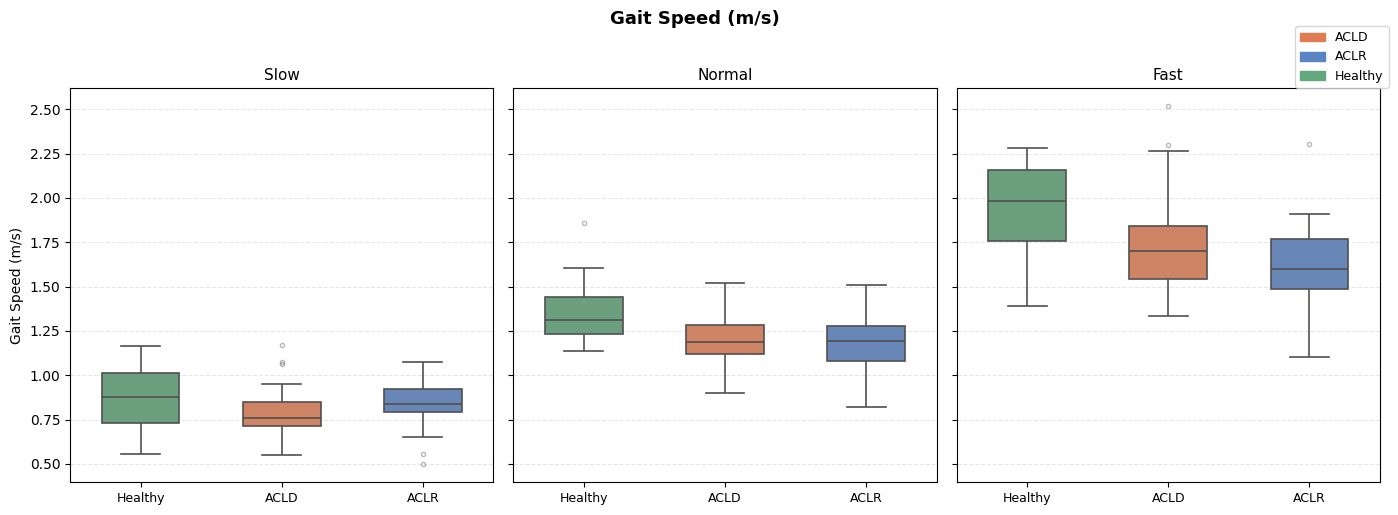

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_cadence_spm.png


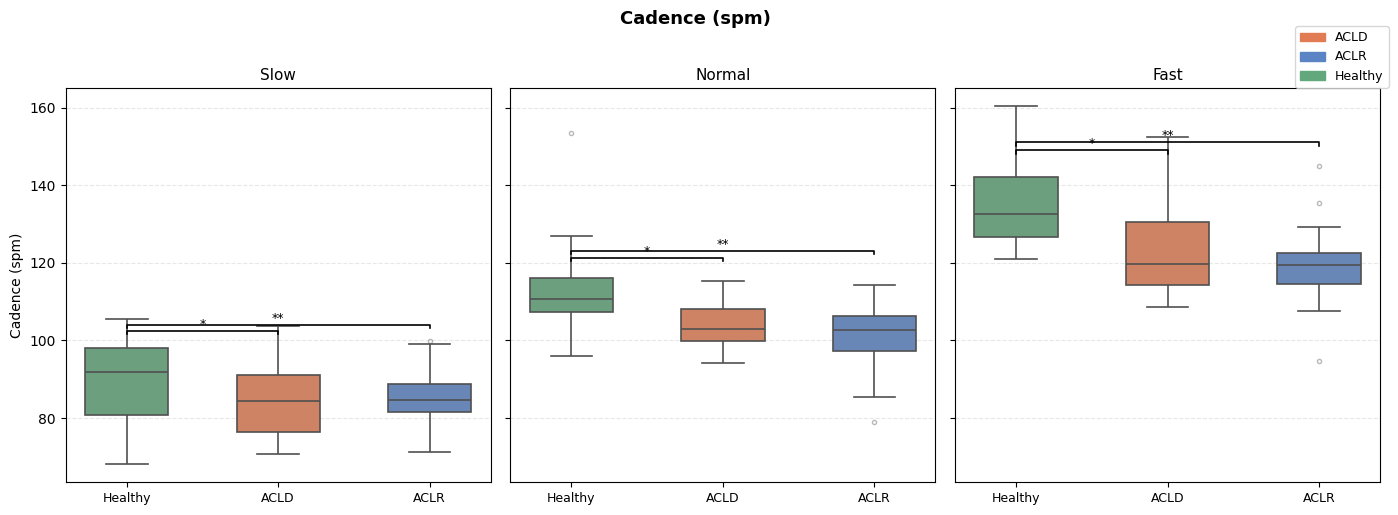

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_stride_length_mean_m.png


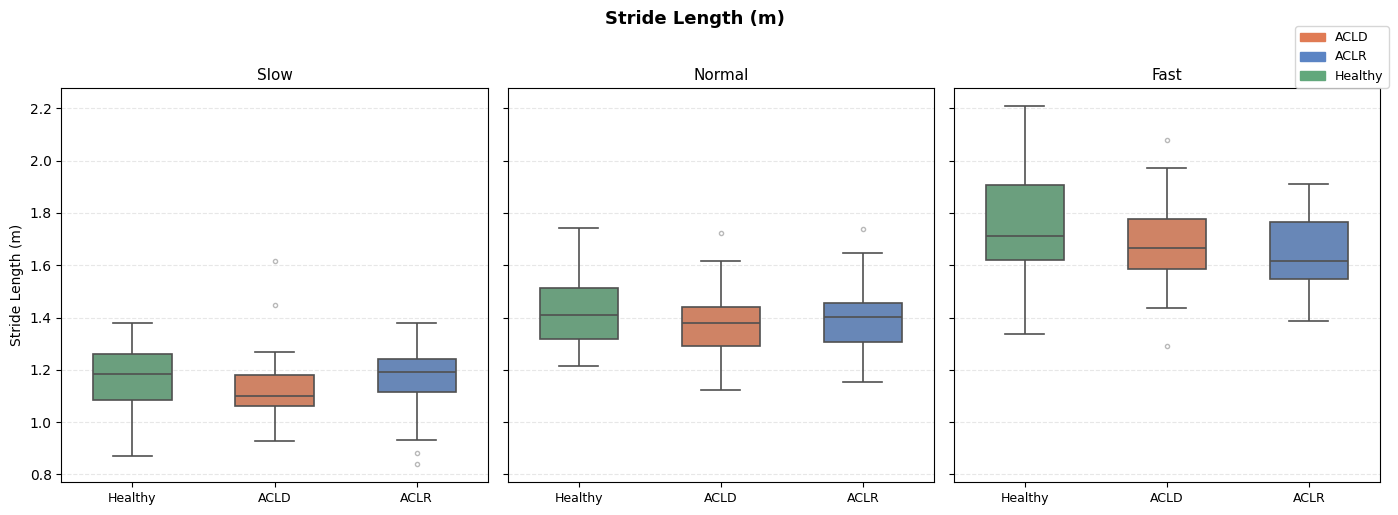

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_step_width_mean_m_orth.png


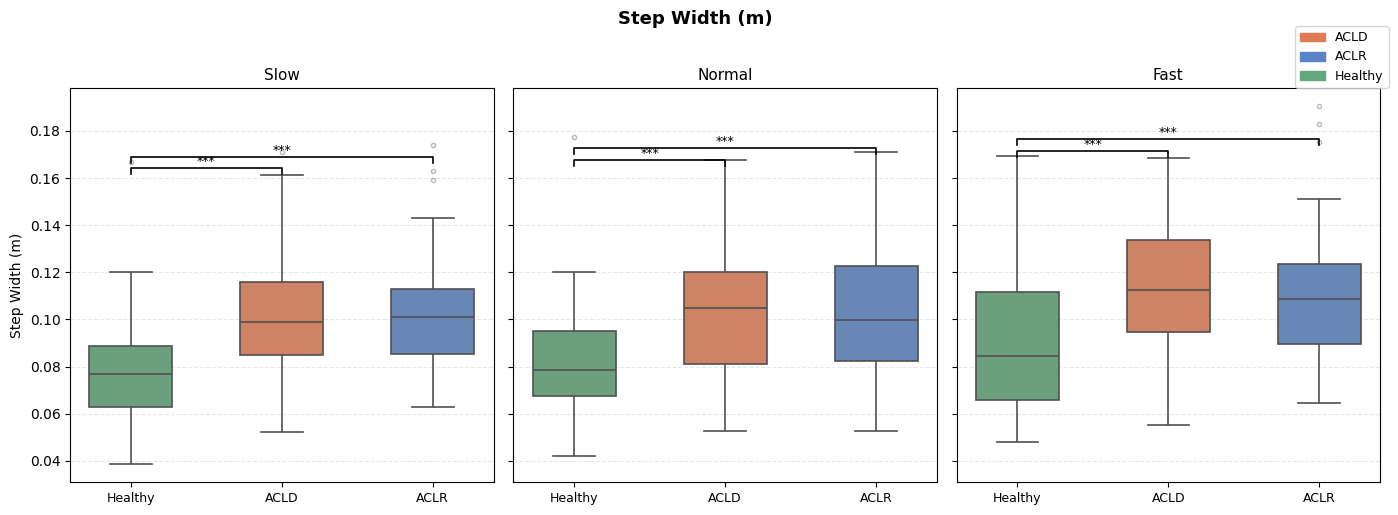

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_double_support_pct.png


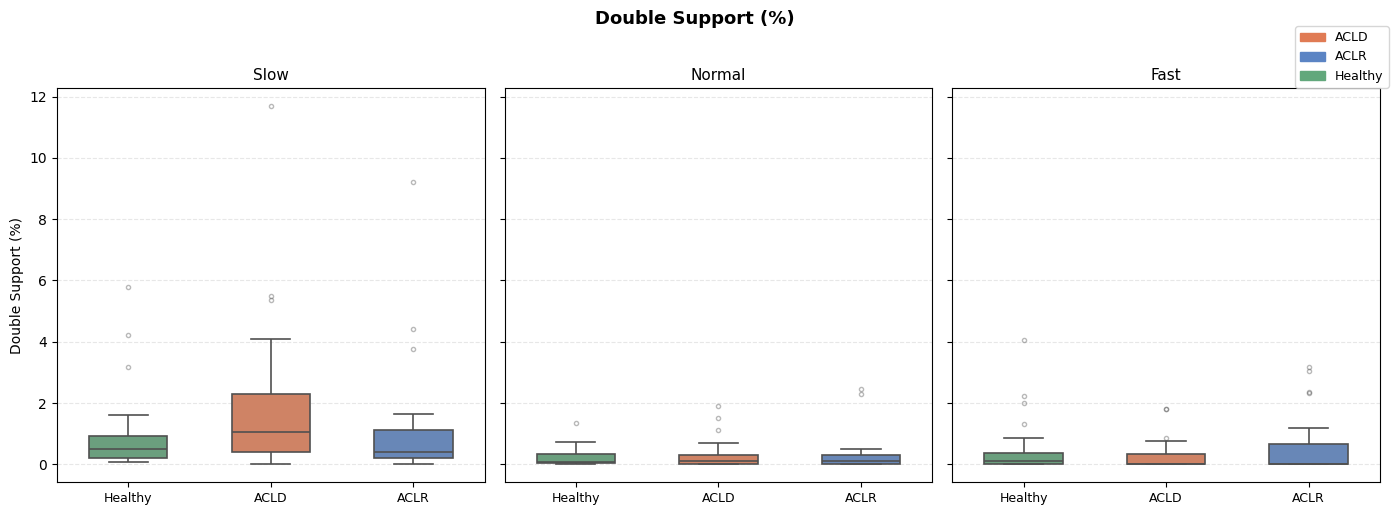

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_single_support_L_pct.png


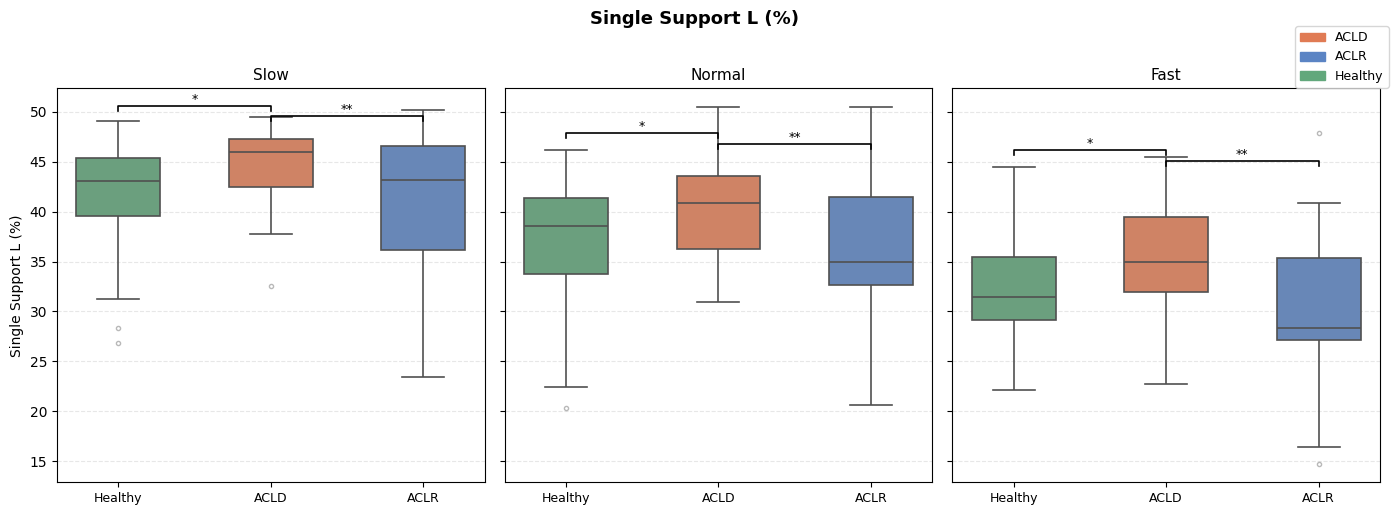

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\boxplot_single_support_R_pct.png


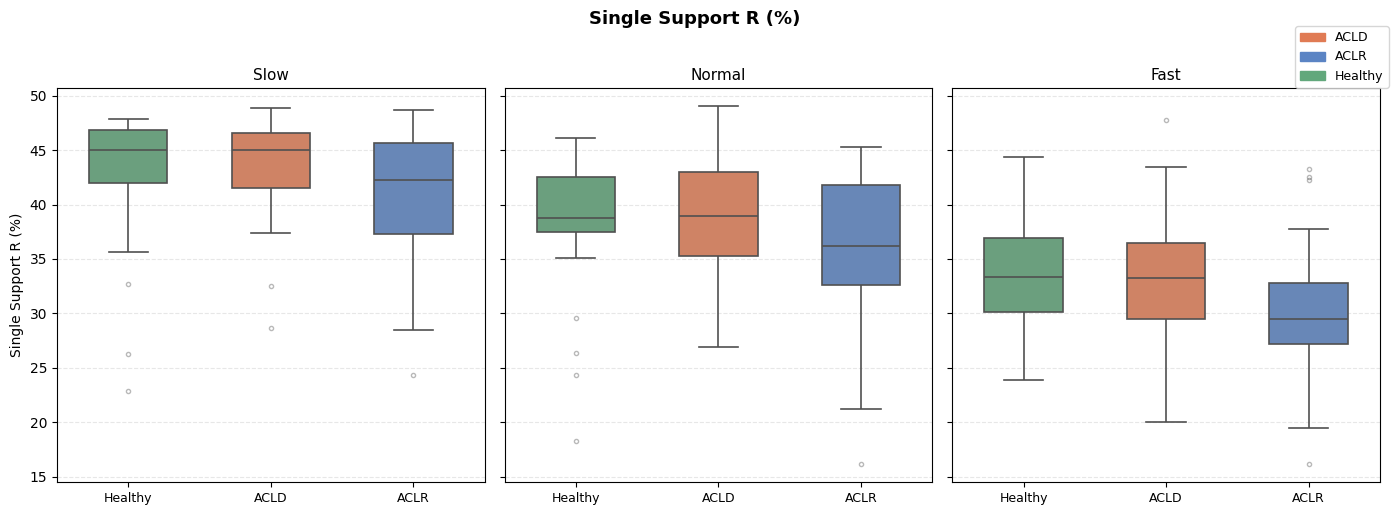

  저장: c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts\correlation_heatmap.png


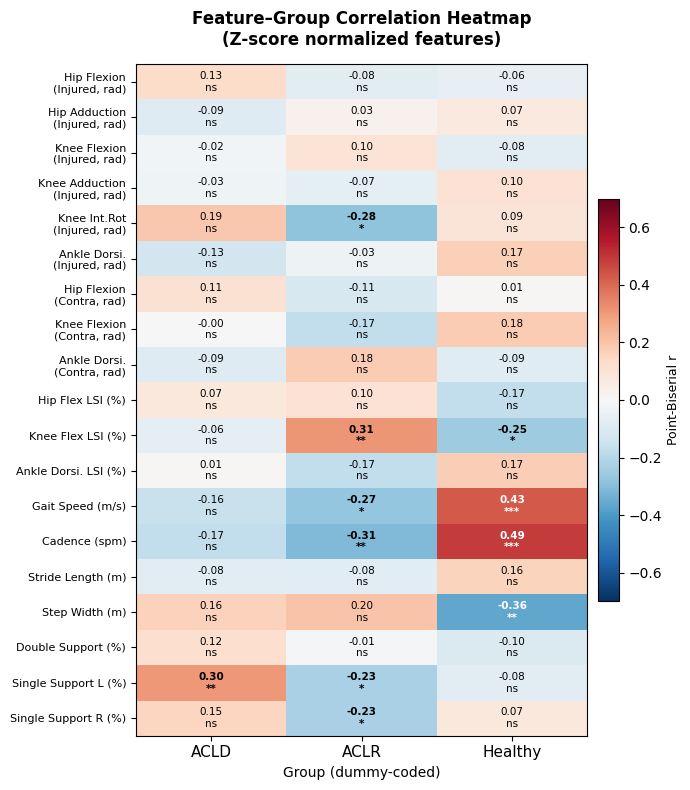

✅ 모든 도표 생성 완료 → c:\Users\kimt9\OneDrive\Desktop\Gal4_PM\ryutt\Walking\artifacts


🎉 모든 파이프라인 실행이 완료되었습니다!


In [4]:

# 3단계: 시각화 (Boxplot + Heatmap)
visualize.run_visualize()

print("🎉 모든 파이프라인 실행이 완료되었습니다!")